# PRISM Doubly Robust Learner Modeling

This notebook is the report-ready doubly robust learner modeling workflow for the PRISM intervention benefit project. It follows the same evaluation framework as `PRISM_Causal_Forest_Modeling_Workflow.ipynb` and produces outputs comparable to `PRISM_Intervention_Benefit_Modeling_README.md`.

Core sign convention:

```text
tau_hat = estimated effect of intervention on outcome_ed_90d
benefit_score = -tau_hat
higher benefit_score = larger estimated ED risk reduction from intervention
```

The workflow uses the same reproducibility seed as all other PRISM workflows: `123`.

## Optional Package Install

Run this cell only if the current notebook kernel is missing `econml`. A Python 3.10–3.13 environment is recommended.

In [1]:
# Uncomment if needed in a compatible Python environment.
# %pip install econml scikit-learn pandas numpy matplotlib openpyxl shap

## Background

Care management programs must decide which members should receive intervention when outreach resources are limited. A common approach is to prioritize the highest-risk members, but high baseline risk does not always mean high intervention benefit. This doubly robust learner workflow focuses on estimating whether intervention benefit varies across members using a doubly robust treatment-effect estimation framework.

## Business Question

Which members are most likely to benefit from intervention in terms of reducing 90-day emergency department utilization, based on doubly robust estimates of heterogeneous treatment effects?

## Project Objectives

- Estimate member-level heterogeneous treatment effects using a doubly robust learner.
- Rank members by estimated intervention benefit.
- Identify high-benefit deciles and subgroup profiles.
- Compare doubly robust rankings with existing T-learner, X-learner, and causal forest outputs.
- Provide explainability through variable importance and SHAP.
- Produce README-ready CSV tables and charts.

## Analytical Task 1: Understanding And Explaining The Doubly Robust Framework

The doubly robust learner estimates a conditional average treatment effect (CATE) for each member. It combines an outcome model with inverse propensity weighting to construct doubly robust pseudo-outcomes, then fits a final random forest regression on those pseudo-outcomes to produce individualized treatment-effect estimates.

The doubly robust property means the treatment-effect estimates remain consistent if either the outcome model or the propensity model is correctly specified. This provides an additional layer of robustness compared with methods that rely on a single nuisance model.

In [2]:
from pathlib import Path
import importlib.util
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = print

if importlib.util.find_spec('econml') is None:
    raise ImportError('Missing required package: econml. Install it in a Python 3.10-3.13 environment, then rerun this notebook.')

from econml.dr import ForestDRLearner

CODE_DIR = Path.cwd()
if CODE_DIR.name.lower() != 'code':
    CODE_DIR = Path.cwd() / 'Code'
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from _prism_model_utils import (
    add_date_features,
    clean_names_simple,
    ensure_output_folder,
    make_design_matrix,
    ntile_desc,
    prepare_model_frame,
    read_prism_excel,
    require_columns,
    split_train_test,
    to_binary,
)

PROJECT_ROOT = CODE_DIR.parent
SEED = 123
TRAIN_FRACTION = 0.70
OUTCOME_COL = 'outcome_ed_90d'
TREATMENT_COL = 'intervention_flag'
OUTPUT_DIR = ensure_output_folder(PROJECT_ROOT / 'Outputs' / 'Doubly-Robust' / 'Python')
COST_PER_ED_VISIT = 1200
COST_PER_INTERVENTION = 250

np.random.seed(SEED)
warnings.filterwarnings('ignore', category=UserWarning)

print(f'Project root: {PROJECT_ROOT}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'Seed: {SEED}')

Project root: /home/sagemaker-user/prism_repo
Output directory: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python
Seed: 123


In [3]:
PATHS = {
    # Task 2
    'predictor_inventory': OUTPUT_DIR / 'doubly_robust_predictor_inventory.csv',
    'data_review_summary': OUTPUT_DIR / 'doubly_robust_data_review_summary.csv',
    # Task 3
    'event_count_summary': OUTPUT_DIR / 'doubly_robust_event_count_summary.csv',
    'propensity_summary': OUTPUT_DIR / 'doubly_robust_propensity_summary.csv',
    'pseudo_outcome_summary': OUTPUT_DIR / 'doubly_robust_pseudo_outcome_summary.csv',
    'propensity_chart': OUTPUT_DIR / 'dashboard_doubly_robust_propensity_overlap.png',
    'pseudo_outcome_chart': OUTPUT_DIR / 'dashboard_doubly_robust_pseudo_outcome_distribution.png',
    # Task 4
    'scored_output': OUTPUT_DIR / 'doubly_robust_scored_output.csv',
    'test_scored_output': OUTPUT_DIR / 'doubly_robust_scored_test_output.csv',
    'effect_distribution_summary': OUTPUT_DIR / 'doubly_robust_effect_distribution_summary.csv',
    'ate_summary': OUTPUT_DIR / 'doubly_robust_ate_summary.csv',
    'true_benefit_validation_summary': OUTPUT_DIR / 'doubly_robust_true_benefit_validation_summary.csv',
    'effect_distribution_chart': OUTPUT_DIR / 'dashboard_doubly_robust_effect_distribution.png',
    # Task 5
    'decile_summary': OUTPUT_DIR / 'doubly_robust_decile_summary.csv',
    'risk_tier_benefit_group_summary': OUTPUT_DIR / 'doubly_robust_risk_tier_benefit_group_summary.csv',
    'top_decile_profile': OUTPUT_DIR / 'doubly_robust_top_decile_profile.csv',
    'consistency_summary': OUTPUT_DIR / 'doubly_robust_cross_method_consistency_summary.csv',
    'top_benefit_examples': OUTPUT_DIR / 'doubly_robust_top_benefit_examples.csv',
    'benefit_decile_chart': OUTPUT_DIR / 'dashboard_doubly_robust_avg_benefit_by_decile.png',
    'risk_tier_benefit_group_chart': OUTPUT_DIR / 'dashboard_doubly_robust_risk_tier_by_benefit_group.png',
    'cross_method_chart': OUTPUT_DIR / 'dashboard_doubly_robust_cross_method_agreement.png',
    # Task 6
    'variable_importance': OUTPUT_DIR / 'doubly_robust_variable_importance.csv',
    'shap_importance': OUTPUT_DIR / 'doubly_robust_global_benefit_shap_importance.csv',
    'shap_values': OUTPUT_DIR / 'doubly_robust_member_benefit_shap_values.csv',
    'variable_importance_chart': OUTPUT_DIR / 'dashboard_doubly_robust_variable_importance.png',
    'shap_chart': OUTPUT_DIR / 'dashboard_doubly_robust_global_benefit_shap.png',
    # Task 7
    'targeting_summary': OUTPUT_DIR / 'doubly_robust_targeting_summary.csv',
    'cumulative_savings_chart': OUTPUT_DIR / 'dashboard_doubly_robust_cumulative_gross_savings_targeting.png',
    'marginal_advantage_chart': OUTPUT_DIR / 'dashboard_doubly_robust_marginal_gross_savings_advantage.png',
}

print(f'PATHS dict defines {len(PATHS)} output targets.')

PATHS dict defines 29 output targets.


In [4]:
def save_csv(df, path):
    """Save DataFrame to CSV and print confirmation."""
    df.to_csv(path, index=False)
    print(f'Saved: {path}')


def save_current_figure(path):
    """Save current matplotlib figure and display it."""
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')


def summarize_distribution(values, label):
    """Return a 9-row percentile summary DataFrame."""
    series = pd.Series(values, dtype=float).dropna()
    return pd.DataFrame({
        'metric': ['mean', 'std_dev', 'min', 'p10', 'p25', 'median', 'p75', 'p90', 'max'],
        label: [
            series.mean(), series.std(), series.min(),
            series.quantile(0.10), series.quantile(0.25), series.median(),
            series.quantile(0.75), series.quantile(0.90), series.max(),
        ],
    })


def safe_corr(a, b, method):
    """NaN-safe correlation between two Series."""
    joined = pd.concat([pd.Series(a, dtype=float), pd.Series(b, dtype=float)], axis=1).dropna()
    if len(joined) < 3:
        return np.nan
    return joined.iloc[:, 0].corr(joined.iloc[:, 1], method=method)


def top_overlap(a_scores, b_scores, share=0.10):
    """Fraction of top-k members shared between two score vectors."""
    a = pd.Series(a_scores).reset_index(drop=True)
    b = pd.Series(b_scores).reset_index(drop=True)
    n = min(len(a), len(b))
    if n == 0:
        return np.nan
    k = max(1, int(np.floor(n * share)))
    return len(set(a.iloc[:n].nlargest(k).index) & set(b.iloc[:n].nlargest(k).index)) / k


def propensity_auc(y_true, scores):
    """Try/except wrapper for ROC AUC."""
    try:
        return roc_auc_score(y_true, scores)
    except Exception:
        return np.nan


def load_shared_propensity_scores():
    """Load exact member-level propensity scores saved by the uplift/X-learner workflow."""
    shared_path = PROJECT_ROOT / 'Outputs' / 'Uplift' / 'Python' / 'X-Learner' / 'shared_propensity_scores.csv'
    if not shared_path.exists():
        return None
    shared = pd.read_csv(shared_path)
    required = {'member_id', 'split', 'propensity_score'}
    missing = required - set(shared.columns)
    if missing:
        raise ValueError(f'Shared propensity file is missing columns: {sorted(missing)}')
    if shared['member_id'].duplicated().any():
        raise ValueError('Shared propensity file has duplicate member_id values.')
    return shared


def merge_shared_propensity(frame, shared_propensity, split_label):
    """Merge exact propensity values by member_id and validate one-to-one matching."""
    if shared_propensity is None:
        return None
    split_scores = shared_propensity[shared_propensity['split'].eq(split_label)].copy()
    merged = frame[['member_id']].merge(
        split_scores[['member_id', 'propensity_score']],
        on='member_id', how='left', validate='one_to_one',
    )
    if merged['propensity_score'].isna().any():
        missing_ids = merged.loc[merged['propensity_score'].isna(), 'member_id'].head().tolist()
        raise ValueError(f'Missing shared propensity for {split_label} member_ids: {missing_ids}')
    return merged['propensity_score'].to_numpy(dtype=float)


print('Helper functions defined.')

Helper functions defined.


## Analytical Task 2: Data Review

This section reviews the modeling population, treatment rate, outcome prevalence, and final model matrix size. These checks are identical to the causal forest and uplift workflows because all PRISM methods use the same source data and predictor set.

In [5]:
df = read_prism_excel()
df.columns = clean_names_simple(df.columns)
df = df.copy()

require_columns(df, [OUTCOME_COL, TREATMENT_COL])
df[OUTCOME_COL] = to_binary(df[OUTCOME_COL])
df[TREATMENT_COL] = to_binary(df[TREATMENT_COL])
df = add_date_features(df, include_duration=False)

PREDICTOR_CATEGORIES = {
    'demographics': ['client_contract', 'service_region', 'program', 'case_manager_name', 'age', 'gender', 'dual_eligible', 'county', 'plan_type', 'language', 'living_alone_flag'],
    'clinical_conditions': ['diabetes_flag', 'chf_flag', 'copd_flag', 'asthma_flag', 'depression_flag', 'anxiety_flag', 'substance_use_flag', 'ckd_flag', 'pregnancy_flag', 'behavioral_health_risk_flag'],
    'sdoh': ['food_insecurity_flag', 'housing_instability_flag', 'transportation_barrier_flag', 'utilities_insecurity_flag'],
    'utilization': ['pcp_visits_last_6m', 'specialist_visits_last_6m', 'ed_visits_last_30d', 'ed_visits_last_6m', 'admits_last_6m', 'observation_stays_last_6m'],
    'pharmacy': ['total_cost_last_6m', 'rx_count_last_6m', 'med_adherence_pdc', 'high_cost_drug_flag', 'opioid_flag', 'polypharmacy_flag'],
    'risk_scores': ['percolator_utilization_score', 'percolator_clinical_score', 'percolator_sdoh_score', 'current_risk_score', 'risk_tier'],
    'intervention_process': ['intervention_type', 'intervention_days_active', 'touches_per_month', 'outreach_attempts', 'successful_contacts', 'avg_call_duration_min', 'max_call_duration_min', 'notes_escalation_flag', 'community_referral_flag', 'pharmacy_review_flag', 'engagement_level'],
    'date_features': ['days_to_intervention_start', 'intervention_start_month', 'intervention_start_wday'],
}
PREDICTOR_VARS = [f for fs in PREDICTOR_CATEGORIES.values() for f in fs]

# Filter to only predictors actually present in the dataset
missing_predictors = [f for f in PREDICTOR_VARS if f not in df.columns]
if missing_predictors:
    print(f'Predictors not found in dataset ({len(missing_predictors)}):')
    print(missing_predictors)
present_predictors = [f for f in PREDICTOR_VARS if f in df.columns]
print(f'\nUsing {len(present_predictors)} of {len(PREDICTOR_VARS)} candidate predictors.')

NUMERIC_VARS = [
    'age', 'pcp_visits_last_6m', 'specialist_visits_last_6m', 'ed_visits_last_30d',
    'ed_visits_last_6m', 'admits_last_6m', 'observation_stays_last_6m',
    'total_cost_last_6m', 'rx_count_last_6m', 'med_adherence_pdc',
    'percolator_utilization_score', 'percolator_clinical_score',
    'percolator_sdoh_score', 'current_risk_score',
    'intervention_start_month', 'intervention_start_wday', 'days_to_intervention_start',
    'intervention_days_active', 'touches_per_month', 'outreach_attempts',
    'successful_contacts', 'avg_call_duration_min', 'max_call_duration_min',
]
BINARY_EXTRA = ['dual_eligible', 'living_alone_flag']

# Predictor inventory
predictor_inventory = pd.DataFrame([
    {
        'feature': feature,
        'category': category,
        'included_in_model': feature in present_predictors,
        'reason_if_excluded': '' if feature in present_predictors else 'Column not present in source data',
        'source_dtype': str(df[feature].dtype) if feature in df.columns else 'missing',
        'unique_values': df[feature].nunique(dropna=True) if feature in df.columns else 0,
    }
    for category, features in PREDICTOR_CATEGORIES.items()
    for feature in features
])
save_csv(predictor_inventory, PATHS['predictor_inventory'])

# Prepare model frame
model_df = prepare_model_frame(df, present_predictors, NUMERIC_VARS, BINARY_EXTRA)
model_df.insert(0, 'member_id', np.arange(len(model_df), dtype=int))
feature_cols_raw = [c for c in model_df.columns if c not in ['member_id', OUTCOME_COL, TREATMENT_COL]]

continuous_count = len([c for c in feature_cols_raw if c in NUMERIC_VARS])
binary_count = len([c for c in feature_cols_raw if c.endswith('_flag') or c in BINARY_EXTRA])
categorical_count = len(feature_cols_raw) - continuous_count - binary_count

# Data review summary
data_review_summary = pd.DataFrame({
    'metric': [
        'Total members', 'Treated members', 'Untreated/control members',
        'Treatment rate', 'ED outcome events', 'Outcome prevalence',
        'Treated observed ED rate', 'Control observed ED rate',
        'Final predictors before one-hot encoding',
        'Continuous/count numeric predictors', 'Binary indicator predictors',
        'Multi-level categorical predictors',
    ],
    'current_value': [
        len(model_df),
        int((model_df[TREATMENT_COL] == 1).sum()),
        int((model_df[TREATMENT_COL] == 0).sum()),
        model_df[TREATMENT_COL].mean(),
        int((model_df[OUTCOME_COL] == 1).sum()),
        model_df[OUTCOME_COL].mean(),
        model_df.loc[model_df[TREATMENT_COL] == 1, OUTCOME_COL].mean(),
        model_df.loc[model_df[TREATMENT_COL] == 0, OUTCOME_COL].mean(),
        len(feature_cols_raw),
        continuous_count,
        binary_count,
        categorical_count,
    ],
})
save_csv(data_review_summary, PATHS['data_review_summary'])
display(data_review_summary)
print(f'\nModel frame: {model_df.shape[0]} rows x {len(feature_cols_raw)} raw predictors')

Imported data from:
https://raw.githubusercontent.com/ndesai777777/prism_repo/main/DataSets/PRP_1000_full_pretreatment.xlsx



Predictors not found in dataset (11):
['intervention_type', 'intervention_days_active', 'touches_per_month', 'outreach_attempts', 'successful_contacts', 'avg_call_duration_min', 'max_call_duration_min', 'notes_escalation_flag', 'community_referral_flag', 'pharmacy_review_flag', 'engagement_level']

Using 45 of 56 candidate predictors.
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_predictor_inventory.csv
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_data_review_summary.csv


/opt/conda/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/conda/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/conda/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,metric,current_value
0,Total members,1000.000000
1,Treated members,394.000000
2,Untreated/control members,606.000000
3,Treatment rate,0.394000
4,ED outcome events,60.000000
5,Outcome prevalence,0.060000
6,Treated observed ED rate,0.040609
7,Control observed ED rate,0.072607
8,Final predictors before one-hot encoding,41.000000
9,Continuous/count numeric predictors,14.000000



Model frame: 1000 rows x 41 raw predictors


---

## Evaluation Roadmap

The remaining analyses are organized into two evaluation stages that build upon one another.

| Evaluation Level | Question | Analytical Tasks |
|---|---|---|
| **Level 1: Treatment-Effect Credibility** | Are the estimated treatment effects sufficiently credible for interpretation and member prioritization? | Tasks 3–5 |
| **Level 2: Explainability And Business Value** | Can the estimated treatment effects be explained and translated into improved targeting decisions? | Tasks 6–7 |

---

# Evaluation Level 1: Treatment-Effect Credibility

**Question:** Are the estimated treatment effects sufficiently credible for interpretation and member prioritization?

The first stage assesses the credibility of the doubly robust treatment-effect estimates through diagnostics, validation against the known synthetic treatment benefit, and cross-method consistency.

---

## Analytical Task 3: Doubly Robust Diagnostics And Estimation Credibility

This section establishes confidence in the doubly robust learner before interpreting treatment effects. It evaluates event counts, propensity overlap, the ForestDRLearner model fit, and pseudo-outcome diagnostics unique to the doubly robust approach.

The primary question is:

> **What evidence suggests that the doubly robust treatment-effect estimates are reliable enough for exploratory prioritization and subgroup discovery?**

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_data_review_summary.csv
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_event_count_summary.csv


,split,group,n,positive_ed_events,negative_ed_events,event_rate
0,Train,Treated,276,11,265,0.039855
1,Train,Control,424,31,393,0.073113
2,Test,Treated,118,5,113,0.042373
3,Test,Control,182,13,169,0.071429


Using shared propensity scores from X-learner workflow.
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_propensity_summary.csv


,metric,value
0,Propensity source,shared_propensity_scores_member_id_merge
1,Train treatment model AUC,0.700275
2,Test treatment model AUC,0.592941
3,Mean propensity,0.402542
4,Min propensity,0.150119
5,5th percentile,0.239062
6,Median propensity,0.384005
7,95th percentile,0.60544
8,Max propensity,0.774384
9,Members below 0.05,0


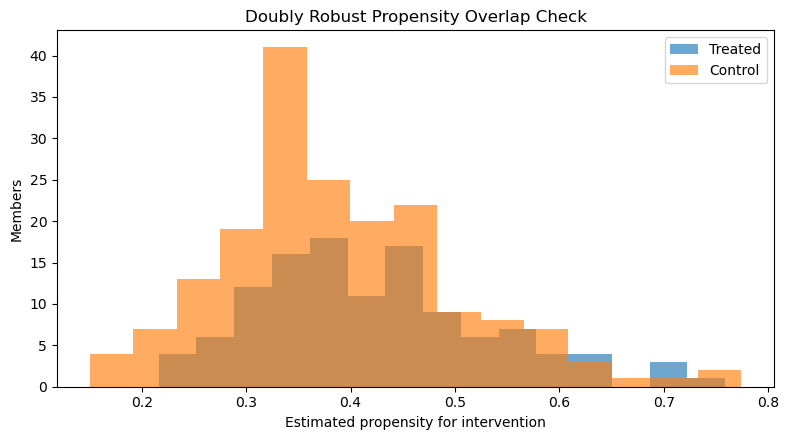

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_propensity_overlap.png


In [6]:
# --- Train/Test Split ---
feature_frame = model_df.drop(columns=['member_id', OUTCOME_COL, TREATMENT_COL])
_, [x_all] = make_design_matrix([feature_frame])

train_df, test_df = split_train_test(
    model_df, train_fraction=TRAIN_FRACTION, seed=SEED,
    stratify_columns=[TREATMENT_COL, OUTCOME_COL],
)
x_train = x_all.loc[train_df.index].reset_index(drop=True)
x_test = x_all.loc[test_df.index].reset_index(drop=True)
y_train = train_df[OUTCOME_COL].astype(float).to_numpy()
w_train = train_df[TREATMENT_COL].astype(float).to_numpy()
y_test = test_df[OUTCOME_COL].astype(float).to_numpy()
w_test = test_df[TREATMENT_COL].astype(float).to_numpy()

# Update data review with model matrix dimensions
data_review_summary = pd.concat([data_review_summary, pd.DataFrame({
    'metric': ['Model matrix columns after one-hot encoding', 'Train rows', 'Test rows'],
    'current_value': [x_all.shape[1], len(train_df), len(test_df)],
})], ignore_index=True)
save_csv(data_review_summary, PATHS['data_review_summary'])

# --- Event Counts ---
event_rows = []
for split_name, frame in [('Train', train_df), ('Test', test_df)]:
    for group_value, group_label in [(1.0, 'Treated'), (0.0, 'Control')]:
        subset = frame[frame[TREATMENT_COL] == group_value]
        positive = int((subset[OUTCOME_COL] == 1).sum())
        n = int(len(subset))
        event_rows.append({
            'split': split_name, 'group': group_label, 'n': n,
            'positive_ed_events': positive, 'negative_ed_events': n - positive,
            'event_rate': positive / n if n else np.nan,
        })
event_count_summary = pd.DataFrame(event_rows)
save_csv(event_count_summary, PATHS['event_count_summary'])
display(event_count_summary)

# --- Shared Propensity Scores ---
shared_propensity_scores = load_shared_propensity_scores()
if shared_propensity_scores is not None:
    train_propensity = merge_shared_propensity(train_df, shared_propensity_scores, 'train')
    test_propensity = merge_shared_propensity(test_df, shared_propensity_scores, 'test')
    propensity_source = 'shared_propensity_scores_member_id_merge'
    print('Using shared propensity scores from X-learner workflow.')
else:
    # Fallback: fit propensity model matching X-learner specification
    from sklearn.pipeline import make_pipeline
    propensity_pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegressionCV(
            Cs=np.logspace(-4, 4, 30),
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
            penalty='elasticnet', solver='saga', l1_ratios=[0.5],
            scoring='roc_auc', max_iter=10000, random_state=SEED, refit=True,
        )
    )
    propensity_pipeline.fit(x_train, w_train)
    train_propensity = np.clip(propensity_pipeline.predict_proba(x_train)[:, 1], 0.05, 0.95)
    test_propensity = np.clip(propensity_pipeline.predict_proba(x_test)[:, 1], 0.05, 0.95)
    propensity_source = 'doubly_robust_matched_glmnet_model_no_shared_file'
    print('Shared propensity file not found; fitted internal propensity model.')

# Propensity summary
prop_series = pd.Series(test_propensity, dtype=float)
propensity_summary = pd.DataFrame({
    'metric': [
        'Propensity source', 'Train treatment model AUC', 'Test treatment model AUC',
        'Mean propensity', 'Min propensity', '5th percentile',
        'Median propensity', '95th percentile', 'Max propensity',
        'Members below 0.05', 'Members above 0.95',
    ],
    'value': [
        propensity_source,
        propensity_auc(w_train, train_propensity),
        propensity_auc(w_test, test_propensity),
        prop_series.mean(), prop_series.min(), prop_series.quantile(0.05),
        prop_series.median(), prop_series.quantile(0.95), prop_series.max(),
        int((prop_series < 0.05).sum()), int((prop_series > 0.95).sum()),
    ],
})
save_csv(propensity_summary, PATHS['propensity_summary'])
display(propensity_summary)

# Propensity overlap chart
plt.figure(figsize=(8, 4.5))
plt.hist(test_propensity[w_test == 1], bins=15, alpha=0.65, label='Treated')
plt.hist(test_propensity[w_test == 0], bins=15, alpha=0.65, label='Control')
plt.xlabel('Estimated propensity for intervention')
plt.ylabel('Members')
plt.title('Doubly Robust Propensity Overlap Check')
plt.legend()
save_current_figure(PATHS['propensity_chart'])

Fitting ForestDRLearner...


ForestDRLearner fitted successfully.
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_pseudo_outcome_summary.csv


,metric,value
0,Source,Training-set effect estimates (proxy for pseud...
1,N,700
2,Mean,-0.043681
3,Std,0.015343
4,Min,-0.095308
5,5th percentile,-0.071252
6,10th percentile,-0.065365
7,25th percentile,-0.052648
8,Median,-0.041715
9,75th percentile,-0.032144


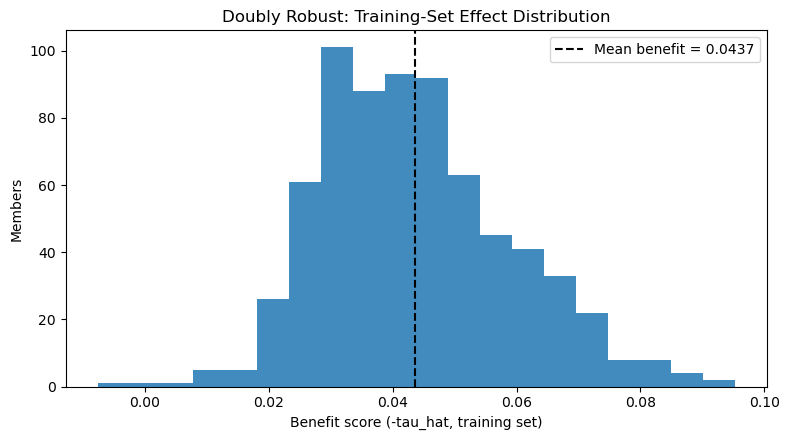

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_pseudo_outcome_distribution.png


In [7]:
# --- Fit ForestDRLearner ---
print('Fitting ForestDRLearner...')
dr_model = ForestDRLearner(
    model_regression=RandomForestRegressor(
        n_estimators=300, min_samples_leaf=10, random_state=SEED, n_jobs=-1,
    ),
    model_propensity=make_pipeline(
        StandardScaler(),
        LogisticRegressionCV(
            Cs=np.logspace(-4, 4, 30),
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
            penalty='elasticnet', solver='saga', l1_ratios=[0.5],
            scoring='roc_auc', max_iter=10000, random_state=SEED, refit=True,
        ),
    ),
    cv=5,
    min_samples_leaf=10,
    n_estimators=500,
    random_state=SEED,
)
dr_model.fit(Y=y_train, T=w_train, X=x_train, W=None)
print('ForestDRLearner fitted successfully.')

# --- Pseudo-Outcome Diagnostics ---
# Reconstruct DR pseudo-outcomes on training data for diagnostic purposes.
# The pseudo-outcome is the doubly robust score that the final model is trained on.
# We reconstruct it using the cross-fitted nuisance predictions.
try:
    # Access internal nuisance model predictions if available
    tau_train_raw = dr_model.effect(x_train).flatten()
    # Use training-set effect estimates as proxy for pseudo-outcome distribution diagnostic
    pseudo_outcomes = tau_train_raw
    pseudo_label = 'Training-set effect estimates (proxy for pseudo-outcomes)'
except Exception as exc:
    print(f'Could not compute training effects: {exc}')
    pseudo_outcomes = np.array([])
    pseudo_label = 'unavailable'

if len(pseudo_outcomes) > 0:
    po_series = pd.Series(pseudo_outcomes, dtype=float)
    pseudo_outcome_summary = pd.DataFrame({
        'metric': [
            'Source', 'N', 'Mean', 'Std', 'Min', '5th percentile',
            '10th percentile', '25th percentile', 'Median',
            '75th percentile', '90th percentile', '95th percentile', 'Max',
            'Fraction negative (benefit direction)',
        ],
        'value': [
            pseudo_label, len(po_series),
            po_series.mean(), po_series.std(), po_series.min(),
            po_series.quantile(0.05), po_series.quantile(0.10),
            po_series.quantile(0.25), po_series.median(),
            po_series.quantile(0.75), po_series.quantile(0.90),
            po_series.quantile(0.95), po_series.max(),
            float((po_series < 0).mean()),
        ],
    })
    save_csv(pseudo_outcome_summary, PATHS['pseudo_outcome_summary'])
    display(pseudo_outcome_summary)

    # Pseudo-outcome distribution chart
    plt.figure(figsize=(8, 4.5))
    plt.hist(-po_series, bins=20, alpha=0.85)
    plt.axvline(-po_series.mean(), linestyle='--', color='black', label=f'Mean benefit = {-po_series.mean():.4f}')
    plt.xlabel('Benefit score (-tau_hat, training set)')
    plt.ylabel('Members')
    plt.title('Doubly Robust: Training-Set Effect Distribution')
    plt.legend()
    save_current_figure(PATHS['pseudo_outcome_chart'])
else:
    print('Pseudo-outcome diagnostics skipped.')

## Analytical Task 4: Treatment Effect Analysis

This section evaluates the final individualized treatment-effect estimates produced by the Doubly Robust Learner. The pseudo-outcomes introduced in Task 3 are an intermediate estimation object used during model training. The analyses below evaluate the final treatment-effect predictions produced by the second-stage forest model.

Each test-set member receives:

```text
tau_hat
benefit_score = -tau_hat
hte_decile
```

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_ate_summary.csv


,metric,value
0,avg_tau_hat,-0.043323
1,avg_benefit_score,0.043323
2,test_members,300.000000


Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_effect_distribution_summary.csv


,metric,benefit_score
0,mean,0.043323
1,std_dev,0.013740
2,min,0.010745
3,p10,0.026929
4,p25,0.033460
5,median,0.040949
6,p75,0.052476
7,p90,0.062530
8,max,0.079788


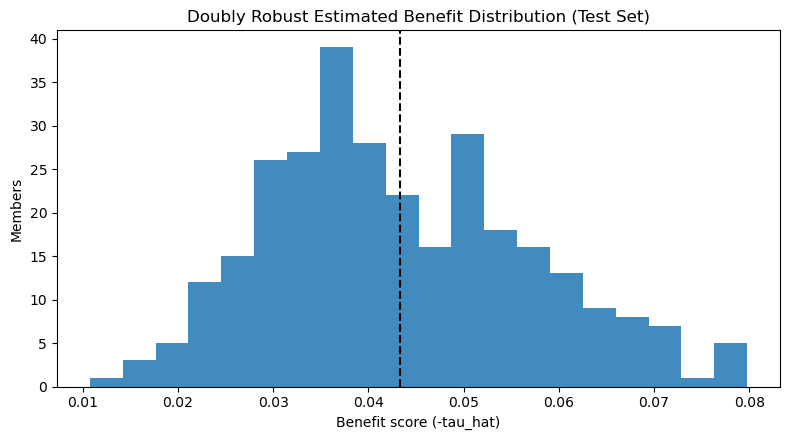

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_effect_distribution.png
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_true_benefit_validation_summary.csv


,model,n_test_members,mean_predicted_benefit,mean_true_benefit,bias,mae,rmse,pearson_corr,spearman_corr
0,Doubly Robust Learner,300,0.043323,0.054813,-0.01149,0.021255,0.027919,0.400615,0.364026


Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_scored_test_output.csv
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_scored_output.csv

Test-set ATE (benefit): 0.0433
Spearman with true benefit: 0.3640
Pearson with true benefit: 0.4006


In [8]:
# --- Predict treatment effects on test set ---
tau_test = dr_model.effect(x_test).flatten().astype(float)

results_test = test_df.reset_index(drop=True).copy()
results_test['tau_hat'] = tau_test
results_test['benefit_score'] = -results_test['tau_hat']
results_test['hte_decile'] = ntile_desc(results_test['benefit_score'], 10).to_numpy()
results_test['uplift_decile'] = results_test['hte_decile']
results_test['propensity_score'] = test_propensity

# --- Treatment Effect Distribution ---
ate_summary = pd.DataFrame({
    'metric': ['avg_tau_hat', 'avg_benefit_score', 'test_members'],
    'value': [results_test['tau_hat'].mean(), results_test['benefit_score'].mean(), len(results_test)],
})
save_csv(ate_summary, PATHS['ate_summary'])
display(ate_summary)

effect_distribution_summary = summarize_distribution(results_test['benefit_score'], 'benefit_score')
save_csv(effect_distribution_summary, PATHS['effect_distribution_summary'])
display(effect_distribution_summary)

# Effect distribution histogram
plt.figure(figsize=(8, 4.5))
plt.hist(results_test['benefit_score'], bins=20, alpha=0.85)
plt.axvline(results_test['benefit_score'].mean(), linestyle='--', color='black')
plt.xlabel('Benefit score (-tau_hat)')
plt.ylabel('Members')
plt.title('Doubly Robust Estimated Benefit Distribution (Test Set)')
save_current_figure(PATHS['effect_distribution_chart'])

# --- Synthetic True-Benefit Validation ---
results_test['true_benefit'] = (
    0.020
    + 0.018 * results_test['ed_visits_last_6m']
    + 0.015 * results_test['admits_last_6m']
    + 0.018 * results_test['food_insecurity_flag']
    + 0.014 * results_test['transportation_barrier_flag']
    + 0.012 * results_test['behavioral_health_risk_flag']
    + 0.0006 * (results_test['current_risk_score'] - 50).clip(lower=0)
)

validation_summary = pd.DataFrame([{
    'model': 'Doubly Robust Learner',
    'n_test_members': len(results_test),
    'mean_predicted_benefit': results_test['benefit_score'].mean(),
    'mean_true_benefit': results_test['true_benefit'].mean(),
    'bias': (results_test['benefit_score'] - results_test['true_benefit']).mean(),
    'mae': (results_test['benefit_score'] - results_test['true_benefit']).abs().mean(),
    'rmse': np.sqrt(((results_test['benefit_score'] - results_test['true_benefit']) ** 2).mean()),
    'pearson_corr': results_test['benefit_score'].corr(results_test['true_benefit'], method='pearson'),
    'spearman_corr': results_test['benefit_score'].corr(results_test['true_benefit'], method='spearman'),
}])
save_csv(validation_summary, PATHS['true_benefit_validation_summary'])
display(validation_summary)

# --- Save scored outputs ---
save_csv(results_test, PATHS['test_scored_output'])

# Full-dataset scoring (using training model on all data)
tau_full = dr_model.effect(x_all).flatten().astype(float)
scored_full = model_df.copy()
scored_full['tau_hat'] = tau_full
scored_full['benefit_score'] = -scored_full['tau_hat']
scored_full['hte_decile'] = ntile_desc(scored_full['benefit_score'], 10).to_numpy()
scored_full['uplift_decile'] = scored_full['hte_decile']
# Merge propensity for all members
if shared_propensity_scores is not None:
    all_propensity = model_df[['member_id']].merge(
        shared_propensity_scores[['member_id', 'propensity_score']],
        on='member_id', how='left', validate='one_to_one',
    )['propensity_score'].to_numpy(dtype=float)
else:
    all_propensity = np.clip(propensity_pipeline.predict_proba(x_all)[:, 1], 0.05, 0.95)
scored_full['propensity_score'] = all_propensity
save_csv(scored_full, PATHS['scored_output'])

print(f'\nTest-set ATE (benefit): {results_test["benefit_score"].mean():.4f}')
print(f'Spearman with true benefit: {validation_summary["spearman_corr"].iloc[0]:.4f}')
print(f'Pearson with true benefit: {validation_summary["pearson_corr"].iloc[0]:.4f}')

## Analytical Task 5: Benefit Decile And High-Value Subgroup Analysis

Members are ranked by `benefit_score` and assigned to HTE deciles. Decile 1 is the highest estimated benefit group. This section also compares the doubly robust rankings against all previously developed causal estimation frameworks.

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_decile_summary.csv


,hte_decile,n,avg_tau_hat,avg_benefit_score,observed_ed_rate,treatment_pct,avg_propensity_score,avg_current_risk_score
0,1,30,-0.069272,0.069272,0.200000,0.400000,0.508307,57.840000
1,2,30,-0.058703,0.058703,0.100000,0.333333,0.480771,52.520000
2,3,30,-0.052864,0.052864,0.000000,0.466667,0.391128,43.686667
3,4,30,-0.048595,0.048595,0.000000,0.333333,0.377440,41.860000
4,5,30,-0.043200,0.043200,0.066667,0.233333,0.405225,42.883333
5,6,30,-0.039096,0.039096,0.133333,0.466667,0.383434,42.580000
6,7,30,-0.036629,0.036629,0.000000,0.366667,0.349465,40.290000
7,8,30,-0.033118,0.033118,0.066667,0.500000,0.392756,40.270000
8,9,30,-0.029446,0.029446,0.000000,0.400000,0.357812,37.723333
9,10,30,-0.022306,0.022306,0.033333,0.433333,0.379083,38.360000


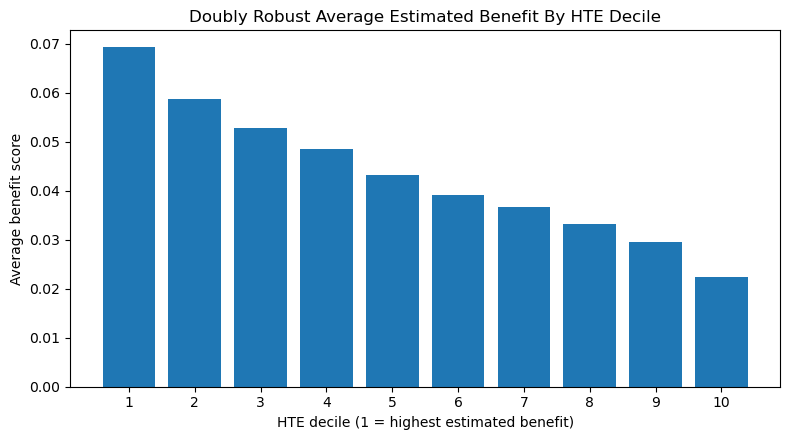

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_avg_benefit_by_decile.png
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_risk_tier_benefit_group_summary.csv


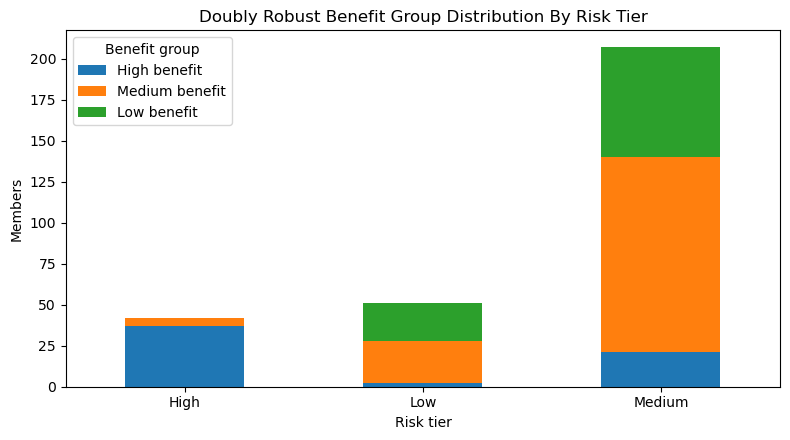

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_risk_tier_by_benefit_group.png
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_top_decile_profile.csv


,feature,top_hte_decile_mean,other_deciles_mean,difference
6,total_cost_last_6m,5675.619667,4069.813593,1605.806074
2,percolator_clinical_score,63.720000,44.332593,19.387407
0,current_risk_score,57.840000,42.241481,15.598519
1,percolator_utilization_score,56.583333,44.317407,12.265926
3,percolator_sdoh_score,41.720000,34.677407,7.042593
4,ed_visits_last_6m,1.733333,0.814815,0.918519
5,admits_last_6m,0.566667,0.333333,0.233333
10,transportation_barrier_flag,0.433333,0.240741,0.192593
12,dual_eligible,0.200000,0.303704,-0.103704
11,utilities_insecurity_flag,0.266667,0.170370,0.096296


In [9]:
# --- Decile Summary ---
agg_map = {
    'n': ('hte_decile', 'size'),
    'avg_tau_hat': ('tau_hat', 'mean'),
    'avg_benefit_score': ('benefit_score', 'mean'),
    'observed_ed_rate': (OUTCOME_COL, 'mean'),
    'treatment_pct': (TREATMENT_COL, 'mean'),
    'avg_propensity_score': ('propensity_score', 'mean'),
}
if 'current_risk_score' in results_test.columns:
    agg_map['avg_current_risk_score'] = ('current_risk_score', 'mean')

decile_summary = results_test.groupby('hte_decile', as_index=False).agg(**agg_map).sort_values('hte_decile')
save_csv(decile_summary, PATHS['decile_summary'])
display(decile_summary)

# Benefit by decile chart
plt.figure(figsize=(8, 4.5))
plt.bar(decile_summary['hte_decile'].astype(str), decile_summary['avg_benefit_score'])
plt.xlabel('HTE decile (1 = highest estimated benefit)')
plt.ylabel('Average benefit score')
plt.title('Doubly Robust Average Estimated Benefit By HTE Decile')
save_current_figure(PATHS['benefit_decile_chart'])

# --- Risk Tier vs Benefit Group ---
results_test['benefit_group'] = pd.cut(
    results_test['hte_decile'],
    bins=[0, 2, 7, 10],
    labels=['High benefit', 'Medium benefit', 'Low benefit'],
)
if 'risk_tier' in results_test.columns:
    risk_benefit_ct = results_test.groupby(['risk_tier', 'benefit_group'], observed=True).size().unstack(fill_value=0)
    risk_benefit_summary = results_test.groupby(['risk_tier', 'benefit_group'], observed=True).size().reset_index(name='n')
    save_csv(risk_benefit_summary, PATHS['risk_tier_benefit_group_summary'])

    # Stacked bar chart
    fig, ax = plt.subplots(figsize=(8, 5.5))
    risk_benefit_ct.plot(kind='bar', stacked=True, ax=ax)
    ax.set_xlabel('Risk Tier')
    ax.set_ylabel('Members')
    ax.set_title('Doubly Robust Benefit Group Distribution By Risk Tier (Test)')
    ax.legend(title='Benefit Group', loc='upper right', bbox_to_anchor=(1.0, 1.0))
    plt.xticks(rotation=0)
    # Add percentage labels inside each bar segment (white text)
    for container in ax.containers:
        labels = [f'{v / risk_benefit_ct.sum(axis=1).iloc[i] * 100:.0f}%' if v > 0 else '' for i, v in enumerate(container.datavalues)]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')
    plt.tight_layout()
    save_current_figure(PATHS['risk_tier_benefit_group_chart'])
else:
    print('risk_tier column not available; skipping risk tier chart.')

# --- Top Decile Profile ---
profile_features = [
    'current_risk_score', 'percolator_utilization_score', 'percolator_clinical_score',
    'percolator_sdoh_score', 'ed_visits_last_6m', 'admits_last_6m', 'total_cost_last_6m',
    'behavioral_health_risk_flag', 'food_insecurity_flag', 'housing_instability_flag',
    'transportation_barrier_flag', 'utilities_insecurity_flag', 'dual_eligible',
]
profile_features = [f for f in profile_features if f in results_test.columns]
top_decile_mask = results_test['hte_decile'] == 1
top_decile_profile = pd.DataFrame([
    {
        'feature': f,
        'top_hte_decile_mean': pd.to_numeric(results_test.loc[top_decile_mask, f], errors='coerce').mean(),
        'other_deciles_mean': pd.to_numeric(results_test.loc[~top_decile_mask, f], errors='coerce').mean(),
    }
    for f in profile_features
])
top_decile_profile['difference'] = top_decile_profile['top_hte_decile_mean'] - top_decile_profile['other_deciles_mean']
top_decile_profile = top_decile_profile.sort_values('difference', key=lambda s: s.abs(), ascending=False)
save_csv(top_decile_profile, PATHS['top_decile_profile'])
display(top_decile_profile)

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_cross_method_consistency_summary.csv


,comparison,n_compared,pearson_corr,spearman_corr,top_10pct_overlap,top_20pct_overlap
0,DR Learner vs GLMNet T-learner,300,0.010758,0.058615,0.233333,0.266667
1,DR Learner vs GLMNet X-learner,300,0.576167,0.560330,0.600000,0.683333
2,DR Learner vs Causal Forest,300,0.894098,0.896790,0.633333,0.766667


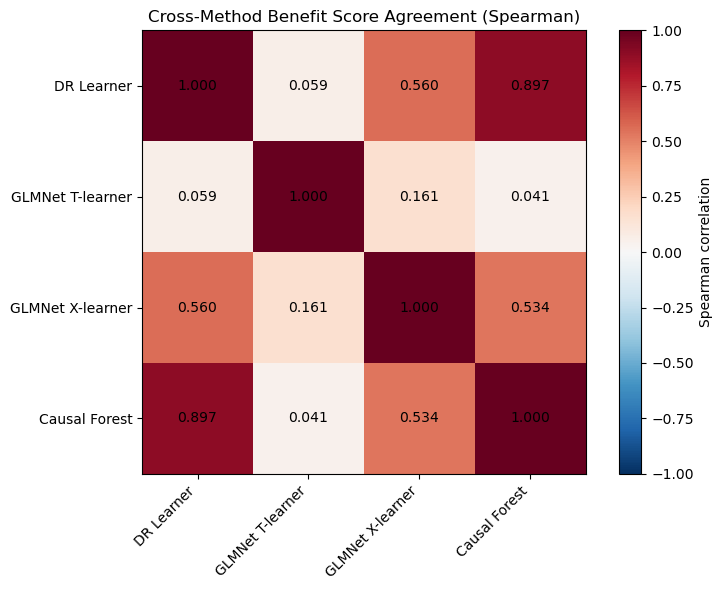

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_cross_method_agreement.png
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_top_benefit_examples.csv


,member_profile,member_id,benefit_score,true_benefit,current_risk_score,hte_decile
0,Highest benefit,620,0.079788,0.0803,60.5,1
1,Lowest benefit,746,0.010745,0.0340,39.2,10
2,"Low risk, high benefit",699,0.064061,0.0500,42.2,1



True-Benefit Top-Group Overlap:
  Top 10%: 11 of 30 (36.7%)
  Top 20%: 33 of 60 (55.0%)


In [10]:
# --- Framework Consistency (4-way comparison) ---
uplift_root = PROJECT_ROOT / 'Outputs' / 'Uplift' / 'Python'
cf_root = PROJECT_ROOT / 'Outputs' / 'Causal-Forests' / 'Python'

comparison_rows = []

def add_comparison(label, scored_path):
    """Compare DR benefit scores against another method's scored output."""
    if not scored_path.exists():
        print(f'Skipping {label}: file not found at {scored_path}')
        return
    other_df = pd.read_csv(scored_path)
    if not {'member_id', 'benefit_score'}.issubset(other_df.columns):
        print(f'Skipping {label}: missing member_id or benefit_score columns.')
        return
    merged = results_test[['member_id', 'benefit_score']].merge(
        other_df[['member_id', 'benefit_score']].rename(columns={'benefit_score': 'other_benefit'}),
        on='member_id', how='inner', validate='one_to_one',
    )
    comparison_rows.append({
        'comparison': f'DR Learner vs {label}',
        'n_compared': len(merged),
        'pearson_corr': safe_corr(merged['benefit_score'], merged['other_benefit'], 'pearson'),
        'spearman_corr': safe_corr(merged['benefit_score'], merged['other_benefit'], 'spearman'),
        'top_10pct_overlap': top_overlap(merged['benefit_score'], merged['other_benefit'], 0.10),
        'top_20pct_overlap': top_overlap(merged['benefit_score'], merged['other_benefit'], 0.20),
    })

add_comparison('GLMNet T-learner', uplift_root / 'T-Learner' / 'GLMNet' / 'uplift_scored_output.csv')
add_comparison('GLMNet X-learner', uplift_root / 'X-Learner' / 'GLMNet' / 'xlearner_scored_test_output.csv')
add_comparison('Causal Forest', cf_root / 'causal_forest_scored_test_output.csv')

consistency_summary = pd.DataFrame(comparison_rows)
save_csv(consistency_summary, PATHS['consistency_summary'])
display(consistency_summary)

# --- Cross-Method Agreement Heatmap ---
# Build pairwise Spearman matrix across all 4 methods
method_scores = {'DR Learner': results_test.set_index('member_id')['benefit_score']}

for label, path in [
    ('GLMNet T-learner', uplift_root / 'T-Learner' / 'GLMNet' / 'uplift_scored_output.csv'),
    ('GLMNet X-learner', uplift_root / 'X-Learner' / 'GLMNet' / 'xlearner_scored_test_output.csv'),
    ('Causal Forest', cf_root / 'causal_forest_scored_test_output.csv'),
]:
    if path.exists():
        tmp = pd.read_csv(path)
        if {'member_id', 'benefit_score'}.issubset(tmp.columns):
            method_scores[label] = tmp.set_index('member_id')['benefit_score']

if len(method_scores) > 1:
    # Align on common member_ids
    common_ids = set.intersection(*[set(s.index) for s in method_scores.values()])
    common_ids = sorted(common_ids)
    score_matrix = pd.DataFrame({k: v.reindex(common_ids) for k, v in method_scores.items()})
    spearman_matrix = score_matrix.corr(method='spearman')

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(spearman_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(spearman_matrix.columns)))
    ax.set_yticks(range(len(spearman_matrix.columns)))
    ax.set_xticklabels(spearman_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(spearman_matrix.columns)
    for i in range(len(spearman_matrix)):
        for j in range(len(spearman_matrix)):
            ax.text(j, i, f'{spearman_matrix.iloc[i, j]:.3f}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, label='Spearman correlation')
    ax.set_title('Cross-Method Benefit Score Agreement (Spearman)')
    save_current_figure(PATHS['cross_method_chart'])
else:
    print('Insufficient methods available for cross-method heatmap.')

# --- Top Benefit Examples ---
ranked = results_test.sort_values('benefit_score', ascending=False)
example_rows_list = []
example_rows_list.append(('Highest benefit', ranked.iloc[0]))
example_rows_list.append(('Lowest benefit', ranked.iloc[-1]))
if 'current_risk_score' in ranked.columns:
    high_risk = ranked['current_risk_score'].quantile(0.75)
    low_benefit = ranked['benefit_score'].quantile(0.25)
    subset = ranked[(ranked['current_risk_score'] >= high_risk) & (ranked['benefit_score'] <= low_benefit)]
    if not subset.empty:
        example_rows_list.append(('High risk, low benefit', subset.iloc[0]))
    low_risk = ranked['current_risk_score'].quantile(0.50)
    high_benefit = ranked['benefit_score'].quantile(0.75)
    subset = ranked[(ranked['current_risk_score'] <= low_risk) & (ranked['benefit_score'] >= high_benefit)]
    if not subset.empty:
        example_rows_list.append(('Low risk, high benefit', subset.iloc[0]))

top_benefit_examples = pd.DataFrame([
    {
        'member_profile': label,
        'member_id': int(row['member_id']),
        'benefit_score': row['benefit_score'],
        'true_benefit': row.get('true_benefit', np.nan),
        'current_risk_score': row.get('current_risk_score', np.nan),
        'hte_decile': row['hte_decile'],
    }
    for label, row in example_rows_list
])
save_csv(top_benefit_examples, PATHS['top_benefit_examples'])
display(top_benefit_examples)

# --- True-Benefit Top-Group Overlap ---
n_test = len(results_test)
top10_n = int(np.ceil(n_test * 0.10))
top20_n = int(np.ceil(n_test * 0.20))
true_top10 = set(results_test.nlargest(top10_n, 'true_benefit')['member_id'])
true_top20 = set(results_test.nlargest(top20_n, 'true_benefit')['member_id'])
dr_top10 = set(results_test.nlargest(top10_n, 'benefit_score')['member_id'])
dr_top20 = set(results_test.nlargest(top20_n, 'benefit_score')['member_id'])
overlap10 = len(dr_top10 & true_top10)
overlap20 = len(dr_top20 & true_top20)
print(f'\nTrue-Benefit Top-Group Overlap:')
print(f'  Top 10%: {overlap10} of {top10_n} ({overlap10/top10_n*100:.1f}%)')
print(f'  Top 20%: {overlap20} of {top20_n} ({overlap20/top20_n*100:.1f}%)')

## Level 1 Summary: Treatment-Effect Credibility

_To be written after all tasks are complete._

---

# Evaluation Level 2: Explainability And Business Value

**Question:** Can the estimated treatment effects be explained and translated into improved targeting decisions?

---

## Analytical Task 6: Variable Importance And Explainability

This section explains which features drive the doubly robust treatment-effect estimates using two complementary methods:

1. **Native Random Forest feature importance** (Gini/MDI importance from the final CATE model)
2. **SHAP global benefit importance** (permutation SHAP on the final benefit-score function)

Both methods describe the fitted treatment-effect model. They should not be interpreted as proving causal mechanisms.

model_final_ not accessible; fitting surrogate RF...


Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_variable_importance.csv


,rank,feature,importance
0,1,current_risk_score,0.513359
1,2,percolator_clinical_score,0.185068
2,3,age,0.132548
3,4,total_cost_last_6m,0.059661
4,5,percolator_utilization_score,0.030718
5,6,percolator_sdoh_score,0.014810
6,7,rx_count_last_6m,0.012252
7,8,pcp_visits_last_6m,0.008844
8,9,program_Complex_CM,0.007196
9,10,med_adherence_pdc,0.007140


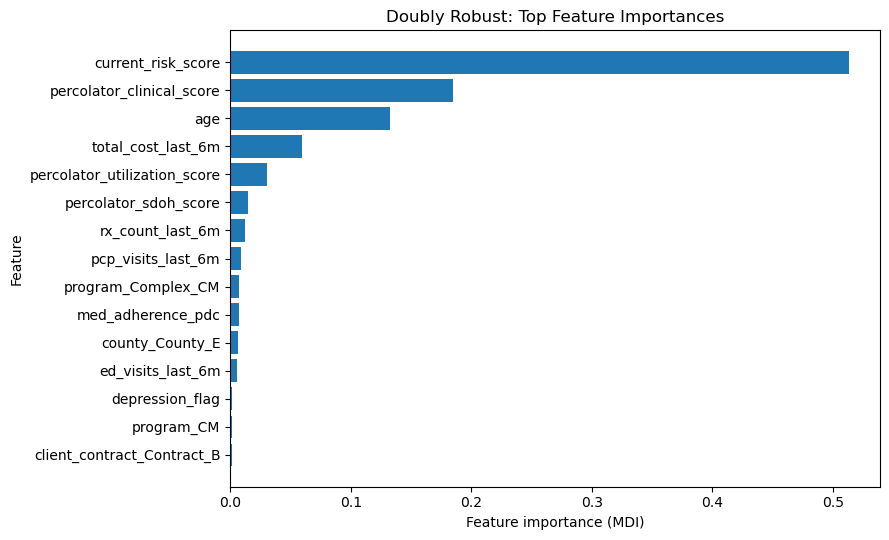

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_variable_importance.png

Computing SHAP values...


PermutationExplainer explainer:   7%|▋         | 22/300 [00:00<?, ?it/s]

PermutationExplainer explainer:   8%|▊         | 24/300 [00:10<00:37,  7.35it/s]

PermutationExplainer explainer:   8%|▊         | 25/300 [00:10<00:53,  5.17it/s]

PermutationExplainer explainer:   9%|▊         | 26/300 [00:10<01:01,  4.48it/s]

...

PermutationExplainer explainer: 100%|██████████| 300/300 [01:25<00:00,  3.67it/s]

PermutationExplainer explainer: 301it [01:26,  3.66it/s]                         

PermutationExplainer explainer: 301it [01:26,  3.24it/s]

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_global_benefit_shap_importance.csv
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_global_benefit_shap_importance.csv
Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_member_benefit_shap_values.csv


,feature,mean_abs_benefit_shap,mean_signed_benefit_shap,mean_positive_benefit_shap,mean_negative_benefit_shap,pct_positive_benefit_shap,pct_negative_benefit_shap
0,percolator_clinical_score,0.004018,0.000209,0.002114,-0.001904,0.250000,0.750000
1,age,0.004014,-0.000122,0.001946,-0.002068,0.333333,0.666667
2,current_risk_score,0.002835,0.000309,0.001572,-0.001263,0.293333,0.706667
3,percolator_utilization_score,0.002153,0.000256,0.001204,-0.000949,0.353333,0.646667
4,med_adherence_pdc,0.002045,-0.000119,0.000963,-0.001082,0.363333,0.636667
5,percolator_sdoh_score,0.001690,-0.000118,0.000786,-0.000904,0.350000,0.650000
6,pcp_visits_last_6m,0.001570,-0.000084,0.000743,-0.000827,0.420000,0.580000
7,ed_visits_last_6m,0.001499,0.000226,0.000863,-0.000636,0.550000,0.450000
8,county_County_E,0.001468,-0.000177,0.000645,-0.000822,0.806667,0.193333
9,rx_count_last_6m,0.001295,0.000310,0.000802,-0.000493,0.430000,0.570000


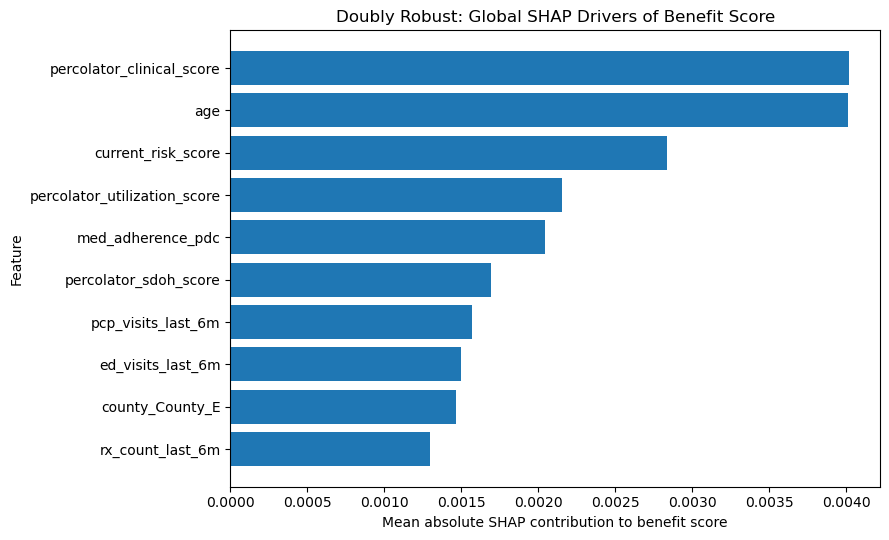

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_global_benefit_shap.png

Known Synthetic Driver Alignment:


,feature,true_contribution_formula,mean_true_contribution,dr_shap_spearman,direction_recovered
0,ed_visits_last_6m,0.018 * ed_visits_last_6m,0.016320,0.815323,Yes
1,admits_last_6m,0.015 * admits_last_6m,0.005350,0.359022,Yes
2,food_insecurity_flag,0.018 * food_insecurity_flag,0.003840,-0.368215,No
3,transportation_barrier_flag,0.014 * transportation_barrier_flag,0.003640,0.160934,Yes
4,behavioral_health_risk_flag,0.012 * behavioral_health_risk_flag,0.004640,-0.442532,No
5,current_risk_score,"0.0006 * max(current_risk_score - 50, 0)",0.001023,0.741232,Yes



True drivers recovered in SHAP top 10: 2 of 6
Recovered: ['ed_visits_last_6m', 'current_risk_score']


In [11]:
import shap

# --- Native RF Variable Importance ---
# Access the final CATE model from ForestDRLearner
try:
    final_model = dr_model.model_final_
    importances = final_model.feature_importances_
    print(f'Accessed model_final_ ({type(final_model).__name__})')
except AttributeError:
    # Fallback: fit a surrogate RF on (x_test, benefit_score)
    print('model_final_ not accessible; fitting surrogate RF...')
    surrogate_rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=10, random_state=SEED, n_jobs=-1)
    surrogate_rf.fit(x_test, results_test['benefit_score'].to_numpy())
    final_model = surrogate_rf
    importances = surrogate_rf.feature_importances_

importance_df = pd.DataFrame({
    'feature': x_test.columns,
    'importance': importances.astype(float),
}).sort_values('importance', ascending=False).reset_index(drop=True)
importance_df.insert(0, 'rank', np.arange(1, len(importance_df) + 1))
save_csv(importance_df, PATHS['variable_importance'])
display(importance_df.head(15))

# Variable importance chart
plot_df = importance_df.head(15).sort_values('importance', ascending=True)
plt.figure(figsize=(9, 5.5))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.xlabel('Feature importance (MDI)')
plt.ylabel('Feature')
plt.title('Doubly Robust: Top Feature Importances')
save_current_figure(PATHS['variable_importance_chart'])

# --- SHAP Benefit-Score Contributions ---
print('\nComputing SHAP values...')

def dr_benefit_predict(x_values):
    """Predict benefit_score = -tau_hat for SHAP."""
    x_df = pd.DataFrame(x_values, columns=x_test.columns) if not isinstance(x_values, pd.DataFrame) else x_values
    tau = dr_model.effect(x_df).flatten().astype(float)
    return -tau

background_sample = shap.sample(x_train, min(100, len(x_train)), random_state=SEED)
masker = shap.maskers.Independent(background_sample)
explainer = shap.Explainer(dr_benefit_predict, masker, algorithm='permutation')
explanation = explainer(x_test, max_evals=2 * len(x_test.columns) + 1)

shap_array = np.asarray(explanation.values, dtype=float)
if shap_array.ndim == 3:
    shap_array = shap_array[:, :, 0]
shap_df = pd.DataFrame(shap_array, columns=x_test.columns)

# Global SHAP importance
feature_columns = list(x_test.columns)
positive_only = shap_df.where(shap_df > 0, 0.0)
negative_only = shap_df.where(shap_df < 0, 0.0)

shap_importance = pd.DataFrame({
    'feature': feature_columns,
    'mean_abs_benefit_shap': shap_df.abs().mean(axis=0).to_numpy(),
    'mean_signed_benefit_shap': shap_df.mean(axis=0).to_numpy(),
    'mean_positive_benefit_shap': positive_only.mean(axis=0).to_numpy(),
    'mean_negative_benefit_shap': negative_only.mean(axis=0).to_numpy(),
    'pct_positive_benefit_shap': shap_df.gt(0).mean(axis=0).to_numpy(),
    'pct_negative_benefit_shap': shap_df.lt(0).mean(axis=0).to_numpy(),
}).sort_values('mean_abs_benefit_shap', ascending=False).reset_index(drop=True)

save_csv(shap_importance, PATHS['shap_importance'])
shap_df.to_csv(PATHS['shap_values'], index=True, index_label='row_index')
print(f'Saved: {PATHS["shap_importance"]}')
print(f'Saved: {PATHS["shap_values"]}')
display(shap_importance.head(10))

# SHAP bar chart
top_shap = shap_importance.head(10).sort_values('mean_abs_benefit_shap', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_shap['feature'], top_shap['mean_abs_benefit_shap'])
ax.set_title('Doubly Robust: Global SHAP Drivers of Benefit Score')
ax.set_xlabel('Mean absolute SHAP contribution to benefit score')
ax.set_ylabel('Feature')
save_current_figure(PATHS['shap_chart'])

# --- Known Synthetic Driver Alignment ---
true_drivers = [
    ('ed_visits_last_6m', '0.018 * ed_visits_last_6m', lambda df: 0.018 * df['ed_visits_last_6m']),
    ('admits_last_6m', '0.015 * admits_last_6m', lambda df: 0.015 * df['admits_last_6m']),
    ('food_insecurity_flag', '0.018 * food_insecurity_flag', lambda df: 0.018 * df['food_insecurity_flag']),
    ('transportation_barrier_flag', '0.014 * transportation_barrier_flag', lambda df: 0.014 * df['transportation_barrier_flag']),
    ('behavioral_health_risk_flag', '0.012 * behavioral_health_risk_flag', lambda df: 0.012 * df['behavioral_health_risk_flag']),
    ('current_risk_score', '0.0006 * max(current_risk_score - 50, 0)', lambda df: 0.0006 * (df['current_risk_score'] - 50).clip(lower=0)),
]

alignment_rows = []
for feature, formula, contrib_fn in true_drivers:
    true_contrib = contrib_fn(results_test)
    mean_true = true_contrib.mean()
    if feature in shap_df.columns:
        spearman = true_contrib.corr(shap_df[feature], method='spearman')
    else:
        spearman = np.nan
    direction = 'Yes' if (not np.isnan(spearman) and spearman > 0.1) else ('No' if (not np.isnan(spearman) and spearman < -0.1) else 'Weak')
    alignment_rows.append({
        'feature': feature,
        'true_contribution_formula': formula,
        'mean_true_contribution': mean_true,
        'dr_shap_spearman': spearman,
        'direction_recovered': direction,
    })

alignment_df = pd.DataFrame(alignment_rows)
print('\nKnown Synthetic Driver Alignment:')
display(alignment_df)

# Driver recovery summary
top10_features = set(shap_importance.head(10)['feature'])
recovered = [f for f, _, _ in true_drivers if f in top10_features]
print(f'\nTrue drivers recovered in SHAP top 10: {len(recovered)} of 6')
print(f'Recovered: {recovered}')

## Analytical Task 7: Business Value Assessment

The business value analysis estimates how much gross savings would be captured when members are targeted by predicted doubly robust benefit versus the prior-style approach of targeting members strictly by highest `current_risk_score`.

The current calculation assumes:

```text
expected_ed_rate_reduction = avg_benefit_score
expected_ed_visits_avoided = n * expected_ed_rate_reduction
gross_savings = expected_ed_visits_avoided * cost_per_ed_visit
intervention_cost = n * cost_per_intervention
net_savings = gross_savings - intervention_cost
roi = net_savings / intervention_cost
```

The current cost assumptions are $1,200 per ED visit and $250 per intervention.

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/doubly_robust_targeting_summary.csv


,targeted_group,members_targeted,dr_gross_savings,risk_gross_savings,advantage,dr_ed_visits_avoided,risk_ed_visits_avoided
0,Top 10%,30,2493.777260,2263.632634,230.144625,2.078148,1.886361
1,Top 20%,60,4607.078837,4323.653246,283.425591,3.839232,3.603044
2,Top 30%,90,6510.169978,5978.121659,532.048319,5.425142,4.981768
3,Top 40%,120,8259.602836,7408.875328,850.727508,6.883002,6.174063
4,Top 50%,150,9814.795696,8752.796760,1061.998935,8.178996,7.293997


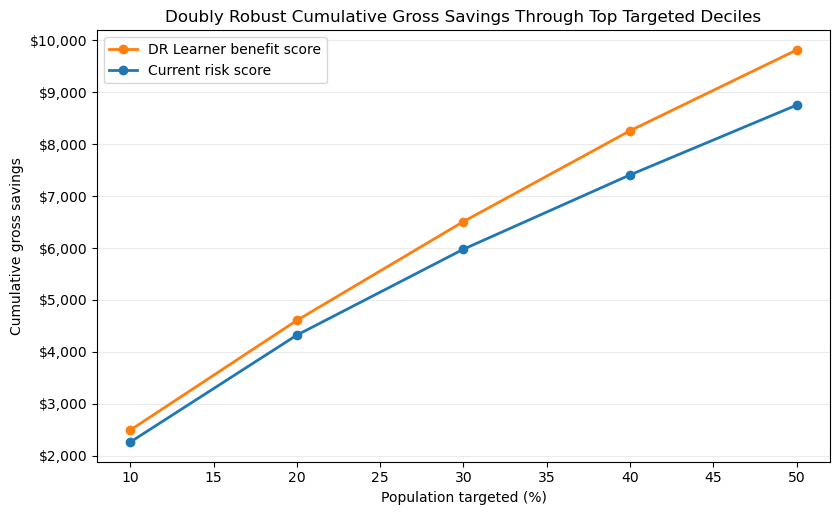

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_cumulative_gross_savings_targeting.png


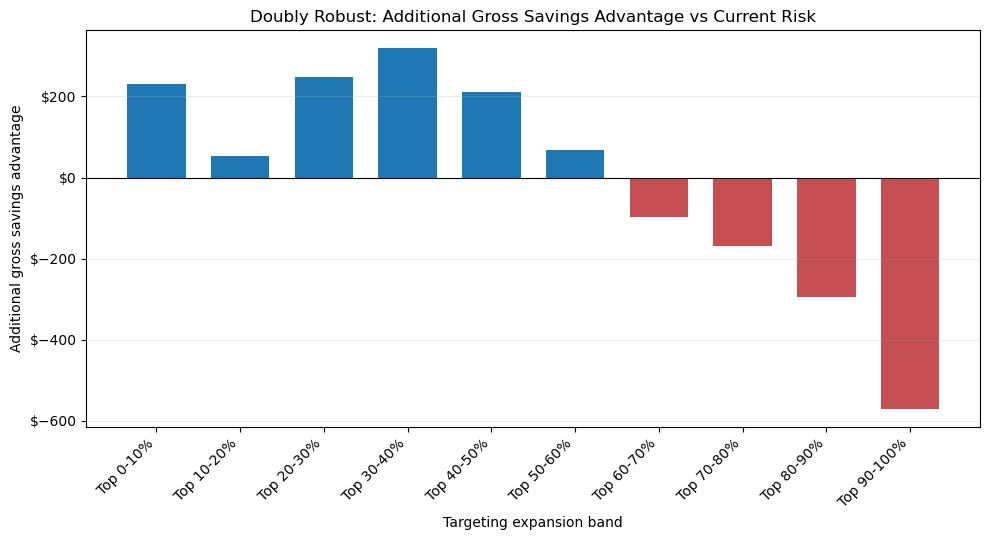

Saved: /home/sagemaker-user/prism_repo/Outputs/Doubly-Robust/Python/dashboard_doubly_robust_marginal_gross_savings_advantage.png

Top 30% targeting comparison:
  DR benefit targeting: $6,510.17
  Current-risk targeting: $5,978.12
  Advantage: $532.05


In [12]:
# --- Cumulative Targeting Comparison ---
n_test = len(results_test)
dr_sorted = results_test.sort_values('benefit_score', ascending=False).reset_index(drop=True)
risk_sorted = results_test.sort_values('current_risk_score', ascending=False).reset_index(drop=True)

pcts = list(range(10, 110, 10))
targeting_rows = []

for pct in pcts:
    n = int(np.ceil(n_test * pct / 100))
    dr_ed = dr_sorted.head(n)['benefit_score'].sum()
    risk_ed = risk_sorted.head(n)['benefit_score'].sum()
    targeting_rows.append({
        'targeted_group': f'Top {pct}%',
        'members_targeted': n,
        'dr_gross_savings': dr_ed * COST_PER_ED_VISIT,
        'risk_gross_savings': risk_ed * COST_PER_ED_VISIT,
        'advantage': (dr_ed - risk_ed) * COST_PER_ED_VISIT,
        'dr_ed_visits_avoided': dr_ed,
        'risk_ed_visits_avoided': risk_ed,
    })

targeting_summary = pd.DataFrame(targeting_rows)
save_csv(targeting_summary, PATHS['targeting_summary'])
display(targeting_summary.head(5))

# --- Cumulative Gross Savings Chart ---
chart_pcts = pcts[:5]  # Top 10% through 50% for line chart
dr_cumulative = [targeting_summary.loc[targeting_summary['targeted_group'] == f'Top {p}%', 'dr_gross_savings'].iloc[0] for p in chart_pcts]
risk_cumulative = [targeting_summary.loc[targeting_summary['targeted_group'] == f'Top {p}%', 'risk_gross_savings'].iloc[0] for p in chart_pcts]

fig, ax = plt.subplots(figsize=(8.5, 5.25))
ax.plot(chart_pcts, dr_cumulative, marker='o', linewidth=2, color='#ff7f0e', label='DR Learner benefit score')
ax.plot(chart_pcts, risk_cumulative, marker='o', linewidth=2, color='#1f77b4', label='Current risk score')
ax.set_title('Doubly Robust Cumulative Gross Savings Through Top Targeted Deciles')
ax.set_xlabel('Population targeted (%)')
ax.set_ylabel('Cumulative gross savings')
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.legend()
ax.grid(axis='y', alpha=0.25)
save_current_figure(PATHS['cumulative_savings_chart'])

# --- Marginal Advantage Bar Chart (all 10 bands) ---
all_dr = [targeting_rows[0]['dr_gross_savings']] + [targeting_rows[i]['dr_gross_savings'] - targeting_rows[i-1]['dr_gross_savings'] for i in range(1, len(targeting_rows))]
all_risk = [targeting_rows[0]['risk_gross_savings']] + [targeting_rows[i]['risk_gross_savings'] - targeting_rows[i-1]['risk_gross_savings'] for i in range(1, len(targeting_rows))]
marginal_advantage = [all_dr[i] - all_risk[i] for i in range(len(all_dr))]
band_labels = [f'Top {pcts[i]-10}-{pcts[i]}%' for i in range(len(pcts))]
colors = ['#1f77b4' if v >= 0 else '#c44e52' for v in marginal_advantage]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(band_labels, marginal_advantage, color=colors, edgecolor='none', width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Doubly Robust: Additional Gross Savings Advantage vs Current Risk')
ax.set_xlabel('Targeting expansion band')
ax.set_ylabel('Additional gross savings advantage')
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=45, ha='right')
save_current_figure(PATHS['marginal_advantage_chart'])

# Summary print
top30 = targeting_summary[targeting_summary['targeted_group'] == 'Top 30%'].iloc[0]
print(f"\nTop 30% targeting comparison:")
print(f"  DR benefit targeting: ${top30['dr_gross_savings']:,.2f}")
print(f"  Current-risk targeting: ${top30['risk_gross_savings']:,.2f}")
print(f"  Advantage: ${top30['advantage']:,.2f}")

## Level 2 Summary: Explainability And Business Value

_To be written after all tasks are complete._

In [13]:
# ============================================================================
# Regenerate README tables/charts from the outputs just produced
# ============================================================================
import subprocess, sys
result = subprocess.run(
    [sys.executable, str(PROJECT_ROOT / "Code" / "generate_all_readmes.py")],
    cwd=str(PROJECT_ROOT), capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print('ERROR:', result.stderr)


PRISM README Generator (unified)

Processing: PRISM_BEST_Confidence_Readme.md
  Updated: PRISM_BEST_Confidence_Readme.md

Processing: PRISM_Causal_Forest_Modeling_README.md
  Updated: PRISM_Causal_Forest_Modeling_README.md

Processing: PRISM_Doubly_Robust_Modeling_README.md
  Updated: PRISM_Doubly_Robust_Modeling_README.md

Processing: PRISM_Intervention_Benefit_Modeling_README.md
  No changes: PRISM_Intervention_Benefit_Modeling_README.md

Done.

